In [1]:
# Примусове налаштування рендерингу графіки в зоні виводу клітинки
%matplotlib inline

# Агресивне автоперезавантаження зовнішніх файлів .py
%load_ext autoreload
%autoreload 2

import os
import sys
from IPython.display import display # Системний виклик рендерингу

# Додавання кореня проєкту до PYTHONPATH
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from feature_analysis import analyze_channel_importance
from visualize import plot_training_metrics
from visualize import visualize_inference

/home/marino/My pc/Diplom/ukan_dfc2020_segmentation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== ЕКСПЕРИМЕНТ 1: CosineAnnealingLR + Class Weights ===
Рендеринг метрик тренування...


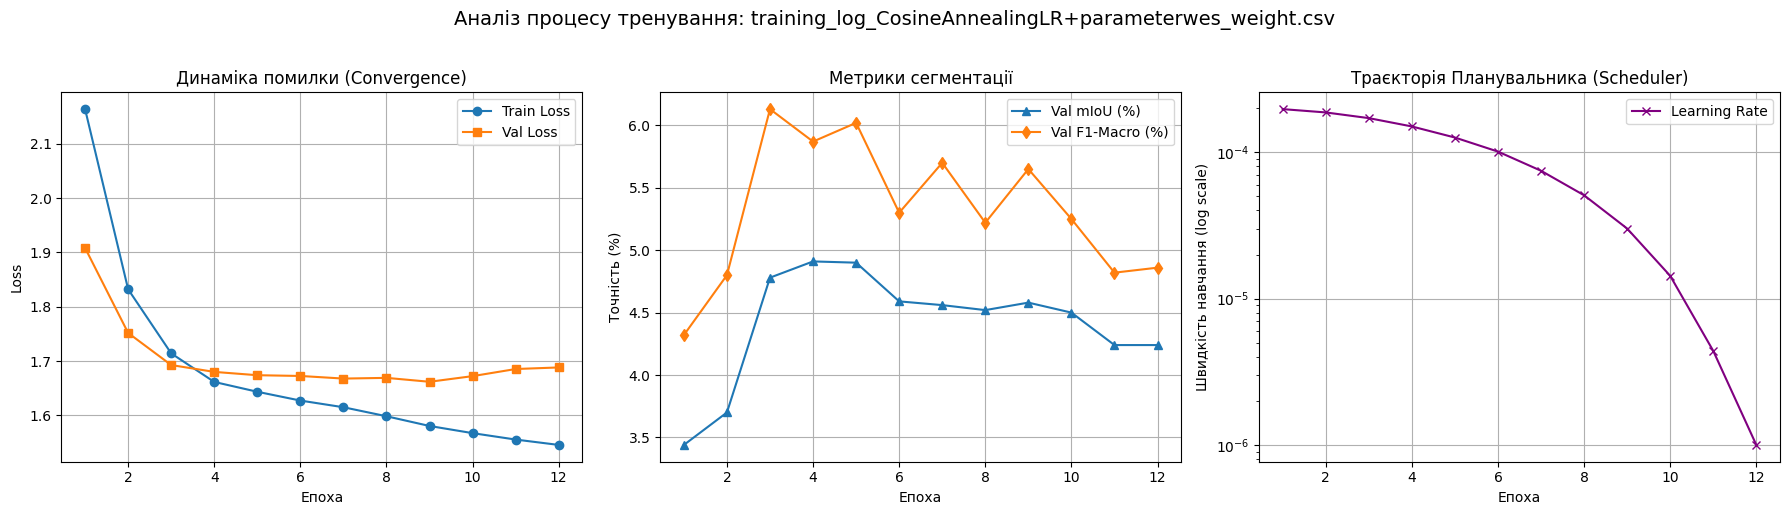

Рендеринг аналізу каналів...


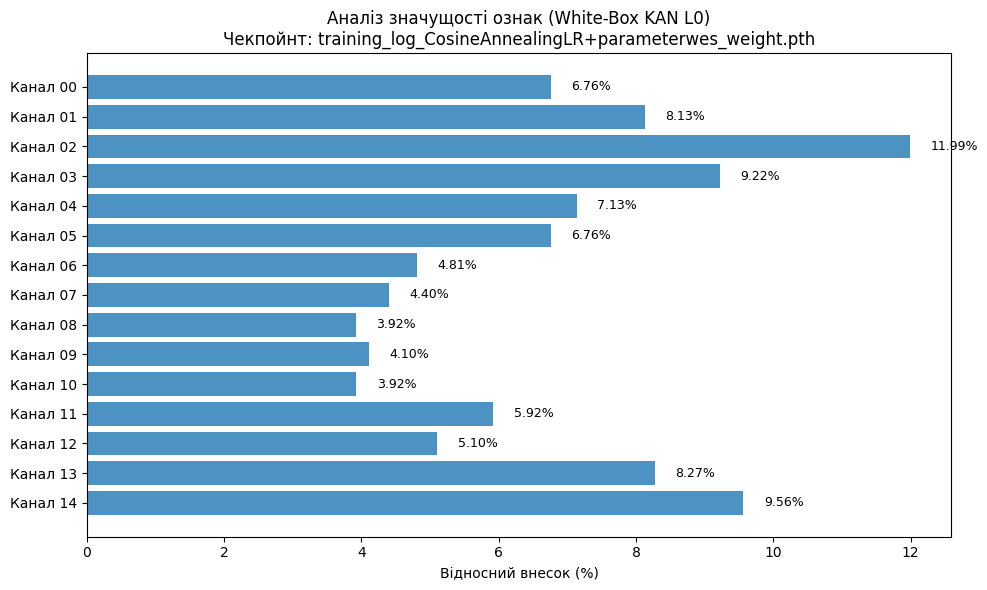

=== ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ СЕГМЕНТАЦІЇ (Знімок vs Еталон vs U-KAN) ===
Ініціалізація прямого проходу (Inference)...


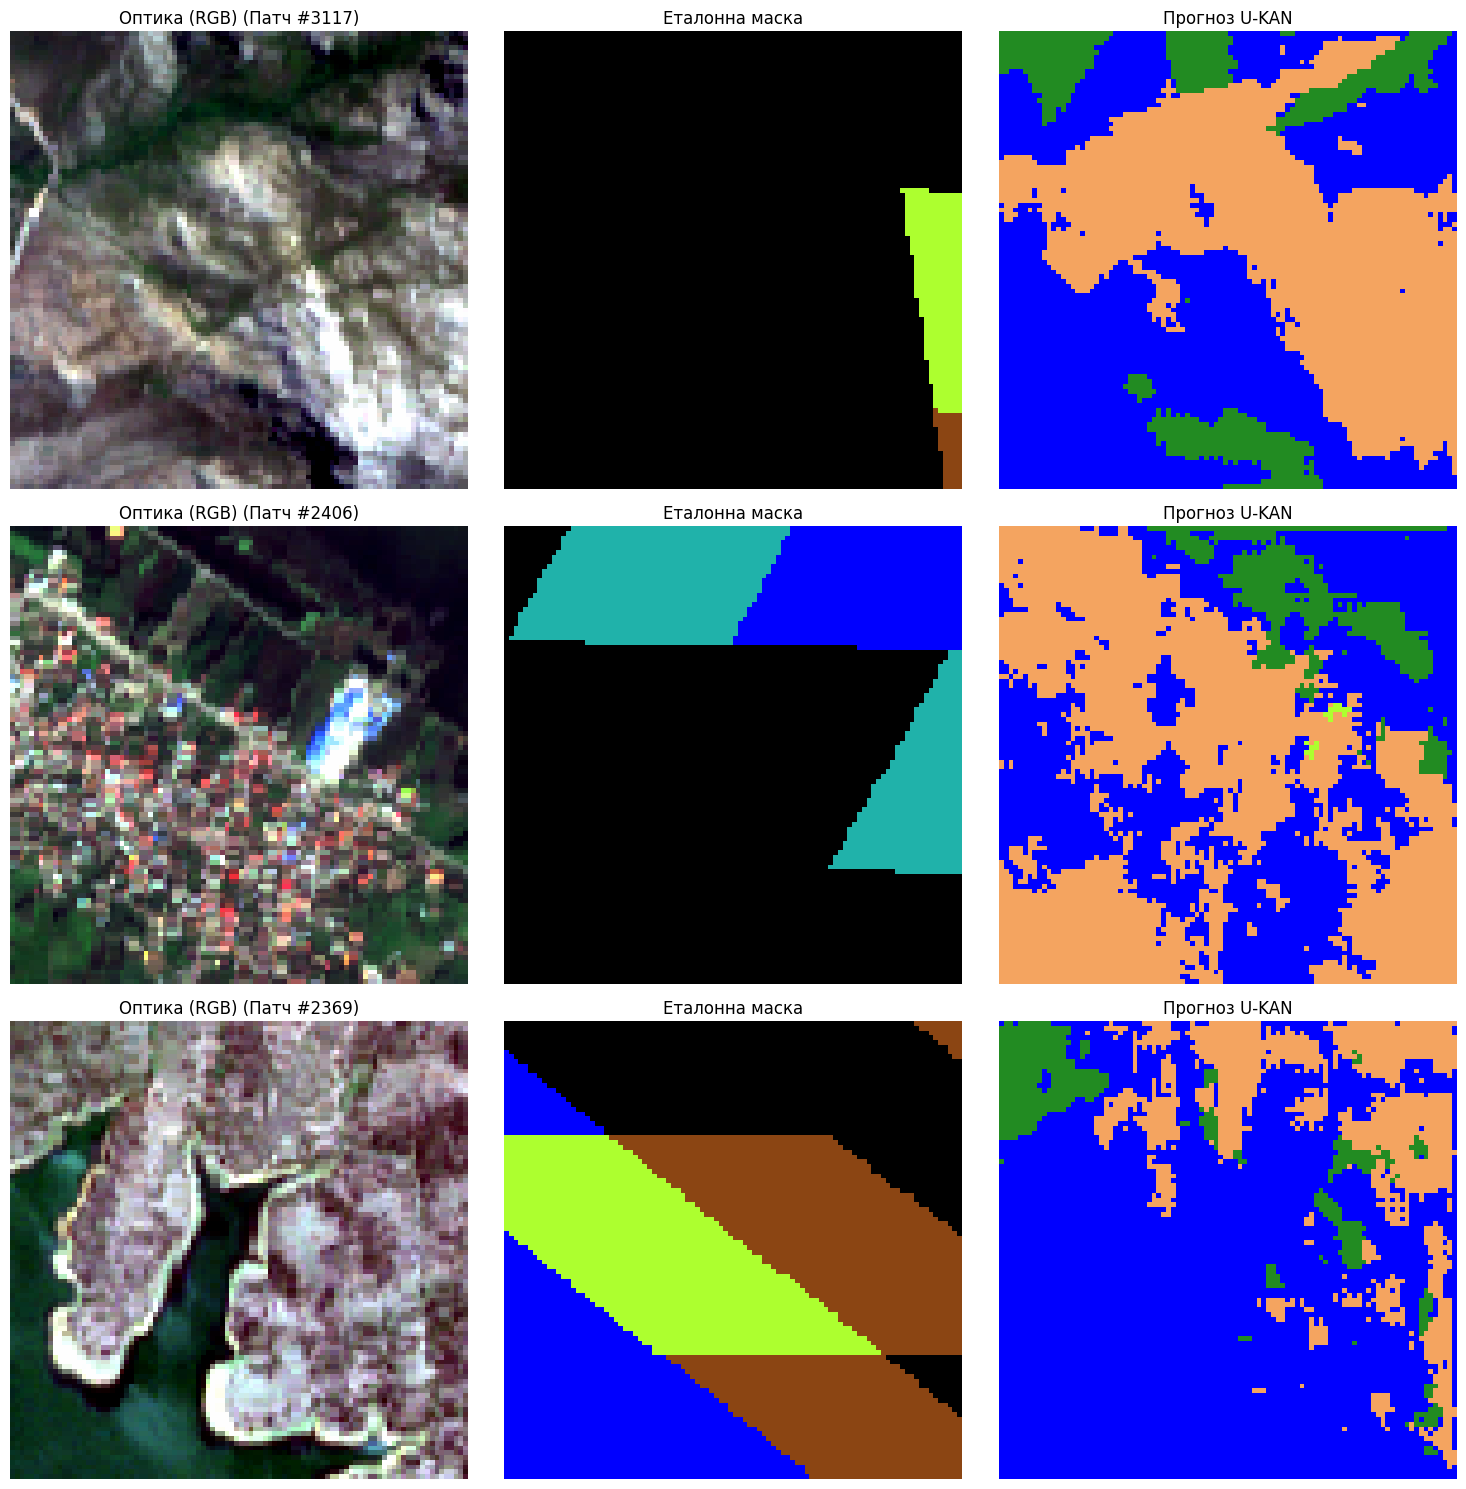

In [3]:
print("=== ЕКСПЕРИМЕНТ 1: CosineAnnealingLR + Class Weights ===")
log_csv_1 = "../checkpoints/training_log_CosineAnnealingLR+parameterwes_weight.csv"
model_pth_1 = "../checkpoints/training_log_CosineAnnealingLR+parameterwes_weight.pth"

# 1. Вивід метрик тренування
fig_metrics_1 = plot_training_metrics(log_csv_1)

# 2. Вивід значущості каналів
fig_channels_1 = analyze_channel_importance(model_pth_1)

# 1. Вивід метрик тренування
print("Рендеринг метрик тренування...")
fig_metrics_2 = plot_training_metrics(log_csv_1, return_fig=True)
display(fig_metrics_2) 

# 2. Вивід гістограми значущості каналів
print("Рендеринг аналізу каналів...")
fig_channels_2 = analyze_channel_importance(model_pth_1, return_fig=True)
display(fig_channels_2)

print("=== ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ СЕГМЕНТАЦІЇ (Знімок vs Еталон vs U-KAN) ===")

# Вкажіть шлях до файлу ваг, який ви хочете перевірити. 
# Наприклад, візьмемо ваги з другого експерименту:
target_weights = "../checkpoints/training_log_GroupNorm+Large_steps.pth"

# Виклик функції. num_samples=3 означає, що буде вибрано 3 випадкові знімки
print("Ініціалізація прямого проходу (Inference)...")
fig_inference = visualize_inference(checkpoint_path=model_pth_1, num_samples=3, return_fig=True)

# Рендеринг зображення на екран
display(fig_inference)

=== ЕКСПЕРИМЕНТ 2: GroupNorm + Gradient Accumulation ===
Рендеринг метрик тренування...


/home/marino/My pc/Diplom/ukan_dfc2020_segmentation/visualize.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


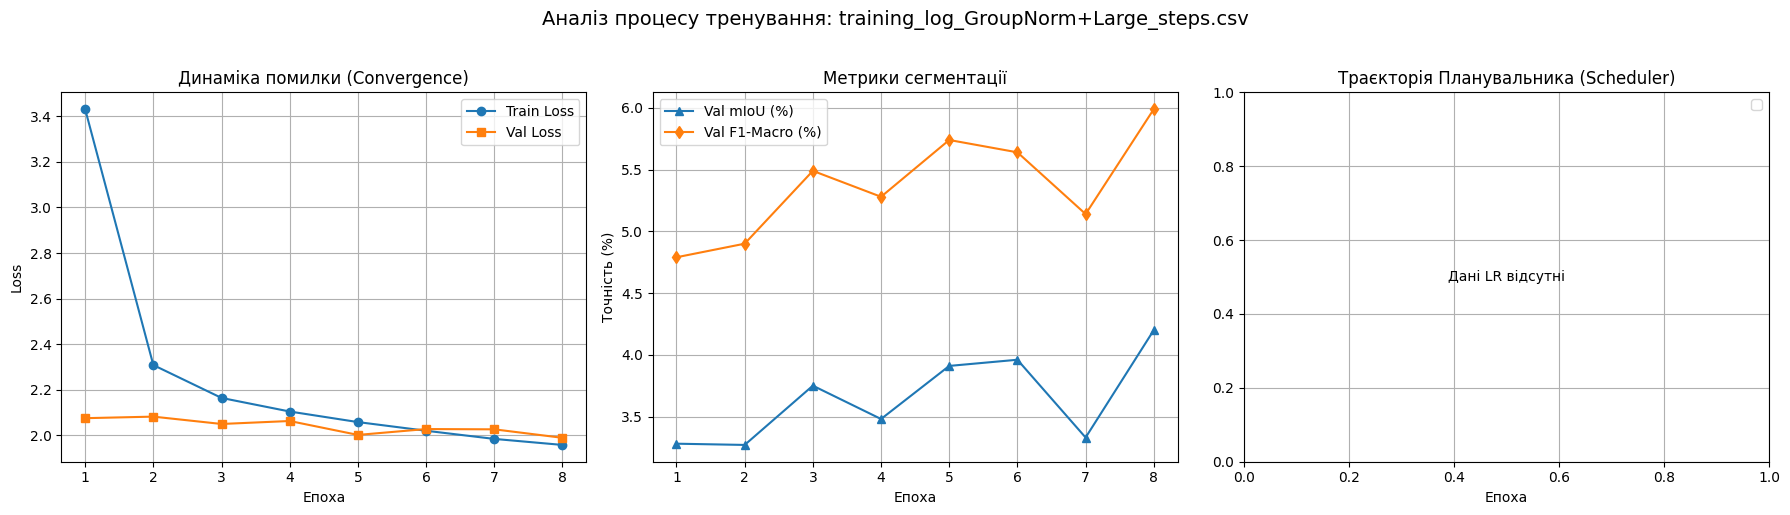

Рендеринг аналізу каналів...


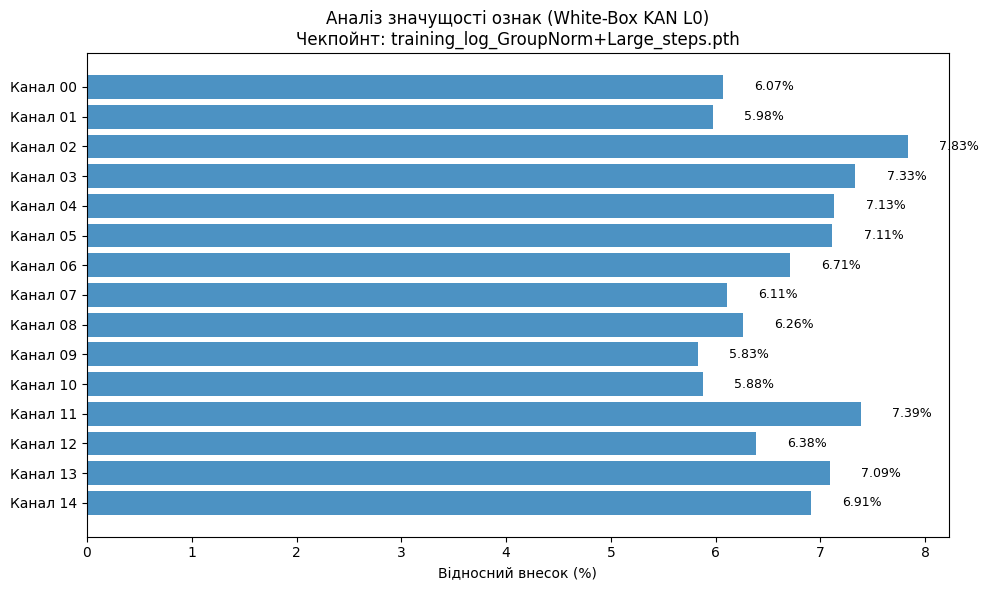

=== ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ СЕГМЕНТАЦІЇ (Знімок vs Еталон vs U-KAN) ===
Ініціалізація прямого проходу (Inference)...


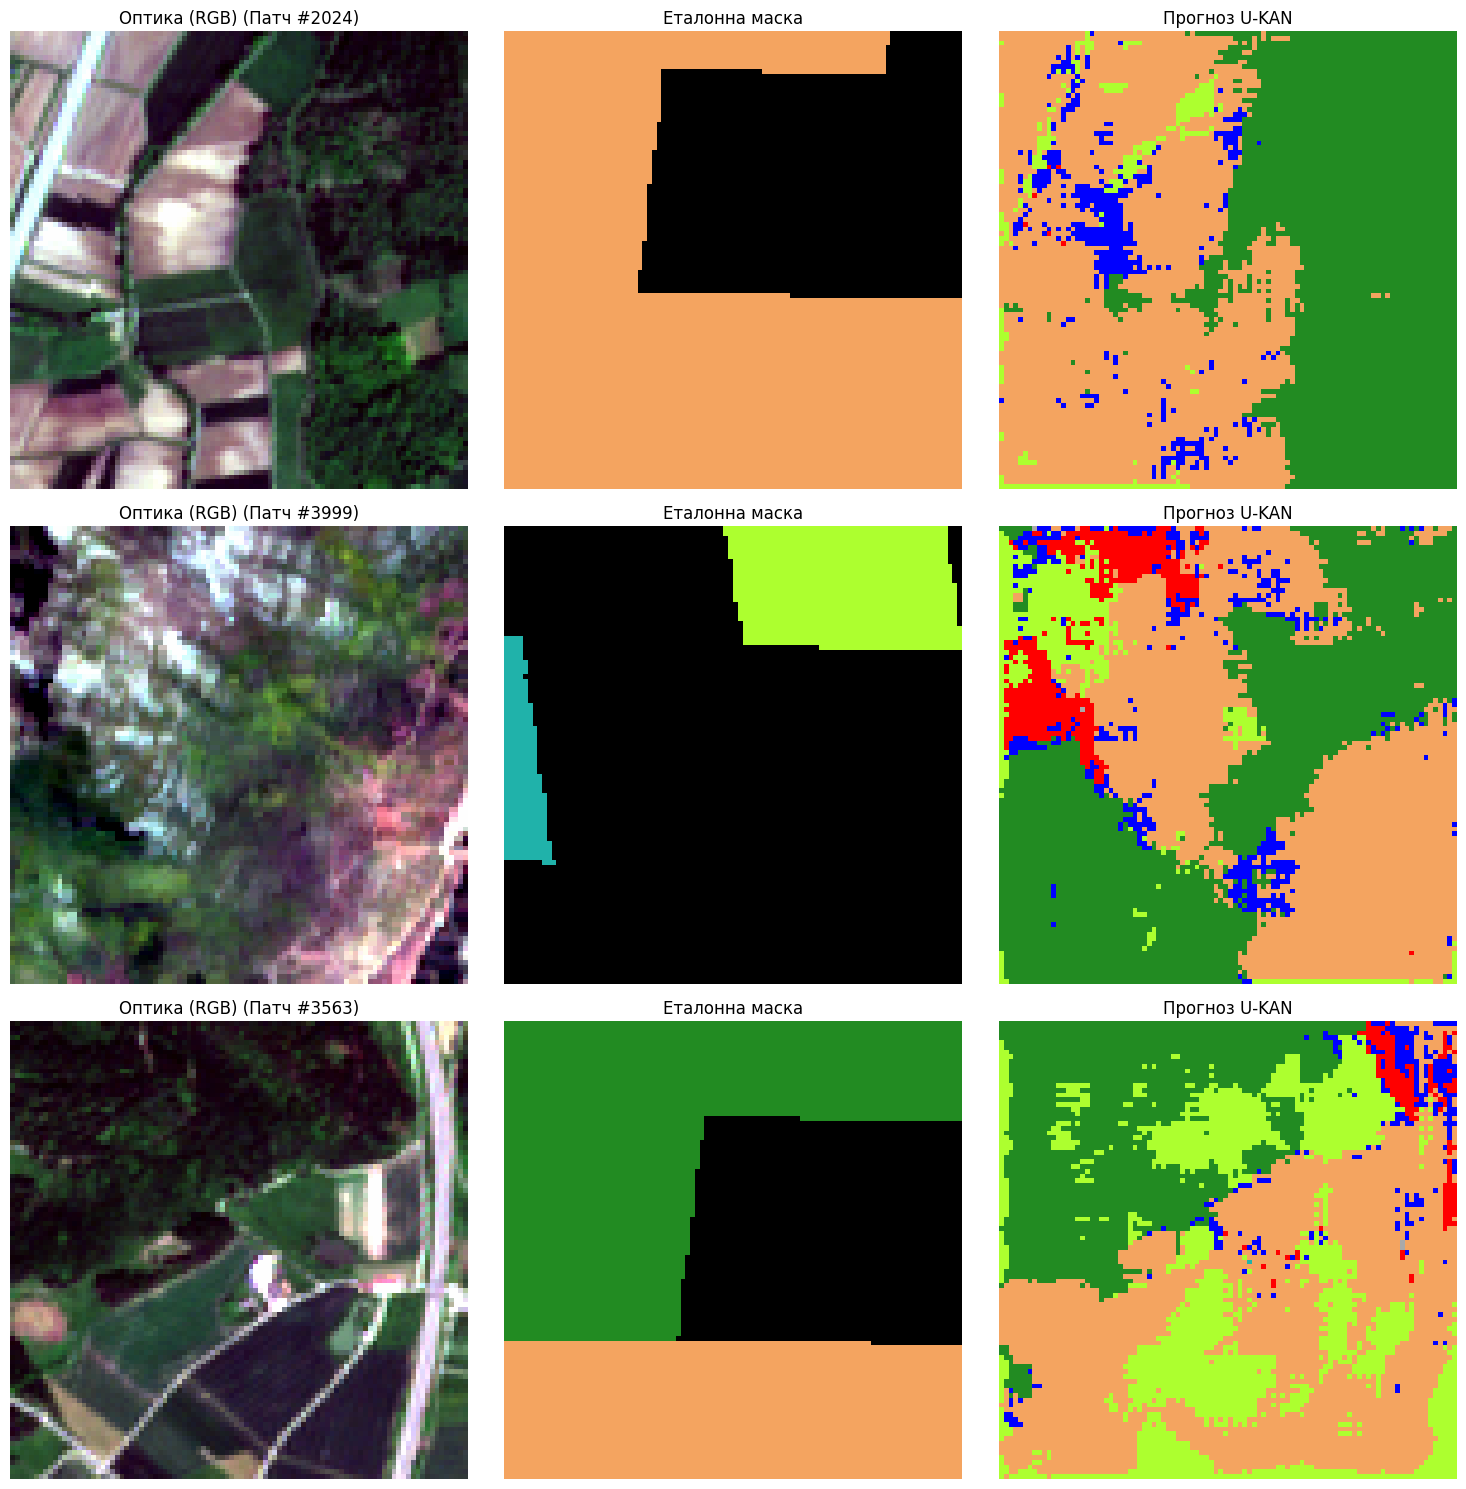

In [4]:
print("=== ЕКСПЕРИМЕНТ 2: GroupNorm + Gradient Accumulation ===")

# Переконайтеся, що ці шляхи є абсолютно точними відносно папки notebooks
log_csv_2 = "../checkpoints/training_log_GroupNorm+Large_steps.csv"
model_pth_2 = "../checkpoints/training_log_GroupNorm+Large_steps.pth"

# 1. Вивід метрик тренування
print("Рендеринг метрик тренування...")
fig_metrics_2 = plot_training_metrics(log_csv_2, return_fig=True)
display(fig_metrics_2) 

# 2. Вивід гістограми значущості каналів
print("Рендеринг аналізу каналів...")
fig_channels_2 = analyze_channel_importance(model_pth_2, return_fig=True)
display(fig_channels_2)

print("=== ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ СЕГМЕНТАЦІЇ (Знімок vs Еталон vs U-KAN) ===")

# Виклик функції. num_samples=3 означає, що буде вибрано 3 випадкові знімки
print("Ініціалізація прямого проходу (Inference)...")
fig_inference = visualize_inference(checkpoint_path=model_pth_2, num_samples=3, return_fig=True)

# Рендеринг зображення на екран
display(fig_inference)